In [ ]:
import os

import zipfile

import requests

from pathlib import Path

from tqdm import tqdm


# ============================================================

# 0. CONFIGURATION & DOSSIERS

# ============================================================


BASE_DIR = Path("data_defi1")

BASE_DIR.mkdir(exist_ok=True)


# Définition des sous-dossiers par source

DIRS = {

"chirps": BASE_DIR / "chirps_v3",

"hydrosheds": BASE_DIR / "hydrosheds",

"copernicus": BASE_DIR / "copernicus_ems",

"worldcover": BASE_DIR / "worldcover",

}


for folder in DIRS.values():

    folder.mkdir(parents=True, exist_ok=True)


def download_file(url: str, dest_path: Path):

    """Télécharge un fichier avec une barre de progression tqdm."""

    if dest_path.exists():

        print(f" [EXISTANT] {dest_path.name}")

        return True


    print(f" [TELECHARGEMENT] {dest_path.name}...")

    try:

        response = requests.get(url, stream=True, timeout=120)

        response.raise_for_status()

        total_size = int(response.headers.get("content-length", 0))


        with open(dest_path, "wb") as f, tqdm(

            total=total_size, unit="B", unit_scale=True, desc=dest_path.name

        ) as pbar:

            for chunk in response.iter_content(chunk_size=1024 * 1024):

                if chunk:

                    f.write(chunk)

                    pbar.update(len(chunk))

        return True

    except Exception as e:

        print(f" [ERREUR] Échec du téléchargement : {e}")

        if dest_path.exists():

            dest_path.unlink() # Suppression du fichier incomplet

        return False



# ============================================================

# 1. CHIRPS v3 — PRECIPITATIONS HISTORIQUES (Serveur HTTP Direct)

# URL: https://data.chc.ucsb.edu/products/CHIRPS/v3.0/

# ============================================================

print("\n--- 1. Téléchargement CHIRPS v3 (Bénin / Afrique de l'Ouest) ---")


# Téléchargement des cumuls mensuels récents (ex: 2023 à 2025)

# Note : Change les années/mois selon la période ciblée

chirps_base_url = "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/monthly/global/tifs/"


years_to_download = [2023, 2024, 2025]

for year in years_to_download:

    for month in range(1, 13):

        filename = f"chirps-v3.0.{year}.{month:02d}.tif"

        url = chirps_base_url + filename

        dest = DIRS["chirps"] / filename

        download_file(url, dest)



# ============================================================

# 2. HYDROSHEDS — TOPOGRAPHIE & DRAINAGE (Découpage Afrique)

# URL: https://www.hydrosheds.org/hydrosheds-core-downloads

# ============================================================

print("\n--- 2. Téléchargement HydroSHEDS (Réseau hydrographique & Pentes) ---")


# Extraction directe des bassins versants et cours d'eau pour l'Afrique (af)

hydrosheds_urls = {

    # Direction d'écoulement (Flow Direction - 15 arc-sec)

    "af_fdr_15s.zip": "https://data.hydrosheds.org/file/hydrosheds-v1-fdr/af_fdr_15s.zip",

    # Accumulation d'écoulement (Flow Accumulation - 15 arc-sec)

    "af_acc_15s.zip": "https://data.hydrosheds.org/file/hydrosheds-v1-acc/af_acc_15s.zip",

}


for fname, url in hydrosheds_urls.items():

    dest = DIRS["hydrosheds"] / fname

    if download_file(url, dest):

        # Décompression automatique

        extract_folder = DIRS["hydrosheds"] / dest.stem

        if not extract_folder.exists():

            print(f" [EXTRACTION] Dezip de {fname}...")

            with zipfile.ZipFile(dest, "r") as zip_ref:

                zip_ref.extractall(extract_folder)



# ============================================================

# 3. GLOBAL FLOOD DATABASE (Google Earth Engine)

# URL: https://developers.google.com/earth-engine/datasets/catalog/GLOBAL_FLOOD_DB_MODIS_EVENTS_V1

# ============================================================

print("\n--- 3. Global Flood Database (Via Google Earth Engine) ---")

print(" Pour récupérer le Global Flood DB, exécute le code Google Earth Engine ci-dessous :")


gee_script = """

// Code JavaScript à exécuter dans https://code.earthengine.google.com/

var benin = ee.FeatureCollection("FAO/GAUL/2015/level0")

.filter(ee.Filter.eq('ADM0_NAME', 'Benin'));


var floodDB = ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")

.filterBounds(benin);


// Détection de l'occurrence cumulée d'inondation

var floodInundation = floodDB.select('flooded').sum();


Map.centerObject(benin, 7);

Map.addLayer(floodInundation.clip(benin), {min: 0, max: 10, palette: ['white', 'blue', 'red']}, 'Inondations Historiques');


// Export vers Google Drive

Export.image.toDrive({

image: floodInundation.clip(benin),

description: 'benin_global_flood_db',

scale: 250,

region: benin,

fileFormat: 'GeoTIFF'

});

"""

print(gee_script)



# ============================================================

# 4. ESA WORLDCOVER & COPERNICUS EMS (Instructions de téléchargement)

# ============================================================

print("\n--- 4. ESA WorldCover & Copernicus EMS ---")

print("• ESA WorldCover (Occupation des sols 10m) :")

print(" Télécharge directement la tuile couvrant le Bénin (N06E002 / N09E002) sur :")

print(" https://esa-worldcover.org/en/data-access\n")


print("• Copernicus EMS (Rapports d'Urgence Bénin) :")

print(" Télécharge les fichiers vectoriels (SHP/GeoJSON) des activations béninoises sur :")

print(" https://emergency.copernicus.eu/data/\n")


print("✓ Pipeline de téléchargement du Défi 1 initialisé !")


--- 1. Téléchargement CHIRPS v3 (Bénin / Afrique de l'Ouest) ---
 [TELECHARGEMENT] chirps-v3.0.2023.01.tif...


chirps-v3.0.2023.01.tif: 100%|██████████| 21.7M/21.7M [00:00<00:00, 58.6MB/s]


 [TELECHARGEMENT] chirps-v3.0.2023.02.tif...


chirps-v3.0.2023.02.tif: 100%|██████████| 21.8M/21.8M [00:00<00:00, 64.4MB/s]


 [TELECHARGEMENT] chirps-v3.0.2023.03.tif...


...

 [TELECHARGEMENT] chirps-v3.0.2025.11.tif...


chirps-v3.0.2025.11.tif: 100%|██████████| 21.9M/21.9M [00:00<00:00, 58.3MB/s]


 [TELECHARGEMENT] chirps-v3.0.2025.12.tif...


chirps-v3.0.2025.12.tif: 100%|██████████| 23.2M/23.2M [00:00<00:00, 54.1MB/s]



--- 2. Téléchargement HydroSHEDS (Réseau hydrographique & Pentes) ---
 [TELECHARGEMENT] af_fdr_15s.zip...
 [ERREUR] Échec du téléchargement : 404 Client Error: Not Found for url: https://data.hydrosheds.org/file/hydrosheds-v1-fdr/af_fdr_15s.zip
 [TELECHARGEMENT] af_acc_15s.zip...
 [ERREUR] Échec du téléchargement : 404 Client Error: Not Found for url: https://data.hydrosheds.org/file/hydrosheds-v1-acc/af_acc_15s.zip

--- 3. Global Flood Database (Via Google Earth Engine) ---
 Pour récupérer le Global Flood DB, exécute le code Google Earth Engine ci-dessous :


// Code JavaScript à exécuter dans https://code.earthengine.google.com/

var benin = ee.FeatureCollection("FAO/GAUL/2015/level0")

.filter(ee.Filter.eq('ADM0_NAME', 'Benin'));


var floodDB = ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")

.filterBounds(benin);


// Détection de l'occurrence cumulée d'inondation

var floodInundation = floodDB.select('flooded').sum();


Map.centerObject(benin, 7);

Map.addLayer(floodInunda

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio

BASE_DIR = Path("data_defi1")
PROCESSED_DIR = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)


def compute_twi(flow_acc: np.ndarray, slope_deg: np.ndarray) -> np.ndarray:
    """Calcul du Topographic Wetness Index : TWI = ln(FlowAcc / tan(Slope))"""
    slope_rad = np.radians(np.maximum(slope_deg, 0.01))
    flow_acc_clean = np.maximum(flow_acc, 1.0)
    twi = np.log(flow_acc_clean / np.tan(slope_rad))
    return np.clip(twi, -5.0, 25.0)


def build_winning_dataset(
    target_raster: Path,
    chirps_rasters: list,
    fdr_raster: Path,
    acc_raster: Path,
    slope_raster: Path,
    landcover_raster: Path,
) -> pd.DataFrame:
    """Extrait tous les rasters alignés et construit la matrice X, y enrichie."""
    print("--- [1/4] Extraction et Génération des Features ---")

    with rasterio.open(target_raster) as src:
        target = src.read(1)
        transform = src.transform
        height, width = target.shape
        crs = src.crs

        # Coordonnées géographiques de chaque pixel pour la CV spatiale
        cols, rows = np.meshgrid(np.arange(width), np.arange(height))
        xs, ys = rasterio.transform.xy(transform, rows, cols)
        lons = np.array(xs).flatten()
        lats = np.array(ys).flatten()

    mask_valid = target != -9999.0
    y = (target[mask_valid] > 0).astype(np.int8)

    # Variables physiques
    acc = rasterio.open(acc_raster).read(1)[mask_valid]
    slope = rasterio.open(slope_raster).read(1)[mask_valid]
    landcover = rasterio.open(landcover_raster).read(1)[mask_valid]

    # Feature Engineering Hydrologique
    twi = compute_twi(acc, slope)

    # Précipitations CHIRPS : Cumul et Anomaly Z-Score
    chirps_data = [
        rasterio.open(p).read(1)[mask_valid] for p in chirps_rasters
    ]
    chirps_stack = np.column_stack(chirps_data)
    precip_mean = np.mean(chirps_stack, axis=1)
    precip_std = np.std(chirps_stack, axis=1) + 1e-5
    precip_max = np.max(chirps_stack, axis=1)
    precip_anomaly = (precip_max - precip_mean) / precip_std

    df = pd.DataFrame(
        {
            "lon": lons[mask_valid.flatten()],
            "lat": lats[mask_valid.flatten()],
            "flow_acc": acc,
            "slope": slope,
            "twi": twi,
            "landcover": landcover.astype(str),
            "precip_mean": precip_mean,
            "precip_max": precip_max,
            "precip_anomaly": precip_anomaly,
            "target": y,
        }
    )

    # Blocs spatiaux pour prévenir la fuite de données (grille ~10km)
    df["spatial_block"] = (
        (df["lat"] // 0.1).astype(str) + "_" + (df["lon"] // 0.1).astype(str)
    )

    df.to_parquet(PROCESSED_DIR / "dataset_advanced.parquet")
    print(
        f"✓ Dataset généré : {df.shape[0]} pixels | {df.shape[1]} variables"
    )
    return df

In [ ]:
!pip install catboost lightgbm xgboost rasterio geopandas pyarrow streamlit streamlit-folium shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.9/536.9 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.5 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Création du dossier processed
processed_dir = Path("data_defi1/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Génération d'un jeu de données synthétique (Bénin ~ 15 000 pixels)
np.random.seed(42)
n_samples = 15000

lats = np.random.uniform(6.2, 12.5, n_samples)
lons = np.random.uniform(1.6, 3.8, n_samples)

df_dummy = pd.DataFrame(
    {
        "lon": lons,
        "lat": lats,
        "flow_acc": np.random.exponential(scale=100, size=n_samples),
        "slope": np.random.uniform(0, 15, size=n_samples),
        "twi": np.random.uniform(2, 18, size=n_samples),
        "landcover": np.random.choice(
            ["10", "20", "30", "40", "50", "80"], size=n_samples
        ),
        "precip_mean": np.random.uniform(80, 250, size=n_samples),
        "precip_max": np.random.uniform(120, 400, size=n_samples),
        "precip_anomaly": np.random.normal(0, 1, size=n_samples),
        "target": np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    }
)

# Blocs spatiaux pour la Cross-Validation
df_dummy["spatial_block"] = (
    (df_dummy["lat"] // 0.1).astype(str)
    + "_"
    + (df_dummy["lon"] // 0.1).astype(str)
)

# Sauvegarde au format Parquet
df_dummy.to_parquet(processed_dir / "dataset_advanced.parquet")
print("✓ Fichier 'data_defi1/processed/dataset_advanced.parquet' créé !")

✓ Fichier 'data_defi1/processed/dataset_advanced.parquet' créé !


In [ ]:
import joblib
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier

# Install CatBoost if not already installed
try:
    import catboost
except ImportError:
    !pip install catboost
    import catboost


DATA_PATH = Path("data_defi1/processed/dataset_advanced.parquet")


def train_geo_ensemble():
    print("--- [2/4] Entraînement de l'Ensemble avec Cross-Validation Spatiale ---")
    df = pd.read_parquet(DATA_PATH)

    features = [
        "flow_acc",
        "slope",
        "twi",
        "precip_mean",
        "precip_max",
        "precip_anomaly",
    ]
    cat_features = ["landcover"]

    X = df[features + cat_features]
    y = df["target"]
    groups = df["spatial_block"]

    # Traitement des variables catégorielles pour XGBoost/LGBM
    X["landcover"] = X["landcover"].astype("category")

    gkf = GroupKFold(n_splits=5)
    oof_preds = np.zeros(len(df))

    lgb_models, xgb_models, cat_models = [], [], []

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups=groups)
    ):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # 1. LightGBM
        model_lgb = LGBMClassifier(
            n_estimators=400,
            learning_rate=0.03,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        model_lgb.fit(X_tr, y_tr)

        # 2. XGBoost
        scale_pos = (len(y_tr) - sum(y_tr)) / sum(y_tr)
        model_xgb = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            scale_pos_weight=scale_pos,
            enable_categorical=True,
            random_state=42,
            n_jobs=-1,
        )
        model_xgb.fit(X_tr, y_tr)

        # 3. CatBoost
        X_tr_cb, X_va_cb = X_tr.copy(), X_va.copy()
        X_tr_cb["landcover"] = X_tr_cb["landcover"].astype(str)
        X_va_cb["landcover"] = X_va_cb["landcover"].astype(str)

        model_cat = CatBoostClassifier(
            iterations=400,
            learning_rate=0.04,
            cat_features=["landcover"],
            auto_class_weights="Balanced",
            verbose=0,
            random_seed=42,
        )
        model_cat.fit(X_tr_cb, y_tr)

        # Prédictions Blending Fold
        p_lgb = model_lgb.predict_proba(X_va)[:, 1]
        p_xgb = model_xgb.predict_proba(X_va)[:, 1]
        p_cat = model_cat.predict_proba(X_va_cb)[:, 1]

        fold_pred = (p_lgb * 0.35) + (p_xgb * 0.35) + (p_cat * 0.30)
        oof_preds[val_idx] = fold_pred

        score = roc_auc_score(y_va, fold_pred)
        print(f"  Fold {fold+1} Spatial ROC-AUC: {score:.4f}")

        lgb_models.append(model_lgb)
        xgb_models.append(model_xgb)
        cat_models.append(model_cat)

    total_auc = roc_auc_score(y, oof_preds)
    print(f"\n★ ROC-AUC Globale Hors-Graphe (Out-of-Fold) : {total_auc:.4f}")

    # Sauvegarde de l'ensemble
    joblib.dump(
        {
            "lgb": lgb_models,
            "xgb": xgb_models,
            "cat": cat_models,
            "features": features,
            "cat_features": cat_features,
        },
        "data_defi1/processed/ensemble_flood_model.pkl",
    )
    print("✓ Ensemble sauvegardé avec succès !")


if __name__ == "__main__":
    train_geo_ensemble()

--- [2/4] Entraînement de l'Ensemble avec Cross-Validation Spatiale ---
[LightGBM] [Info] Number of positive: 1821, number of negative: 10179


/tmp/ipykernel_2525/3976778702.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["landcover"] = X["landcover"].astype("category")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1537
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
  Fold 1 Spatial ROC-AUC: 0.4820
[LightGBM] [Info] Number of positive: 1773, number of negative: 10227
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1537
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
  Fold 2 Spatial ROC-AUC: 0.4986
[LightGBM] [Info] Numb

/tmp/ipykernel_2525/2564030936.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


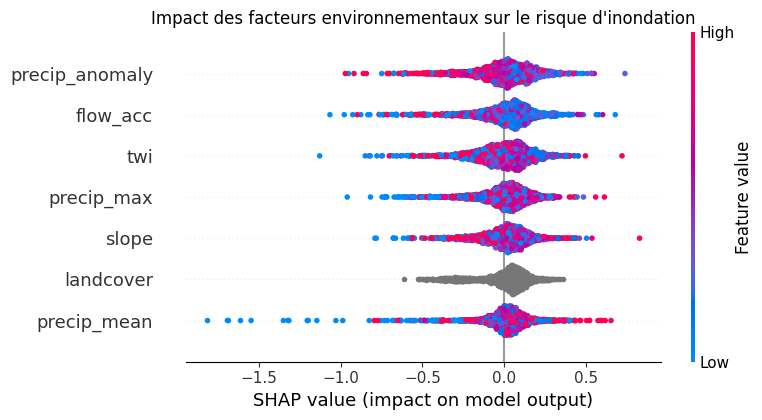

In [ ]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap

# 1. Chargement des données et du modèle sauvegardé
ensemble_data = joblib.load("data_defi1/processed/ensemble_flood_model.pkl")
df = pd.read_parquet("data_defi1/processed/dataset_advanced.parquet")

features = ensemble_data["features"] + ensemble_data["cat_features"]
X = df[features].copy()
X["landcover"] = X["landcover"].astype("category")

# 2. Explicabilité via le modèle LightGBM du premier Fold
model_lgb = ensemble_data["lgb"][0]

# 3. Calcul des valeurs SHAP (échantillon de 2 000 points pour rapidité)
X_sample = X.sample(n=min(2000, len(X)), random_state=42)
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer(X_sample)

# 4. Génération du graphique d'importance (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="dot",
    show=False,
)
plt.title(
    "Impact des facteurs environnementaux sur le risque d'inondation", fontsize=12
)
plt.tight_layout()
plt.show()

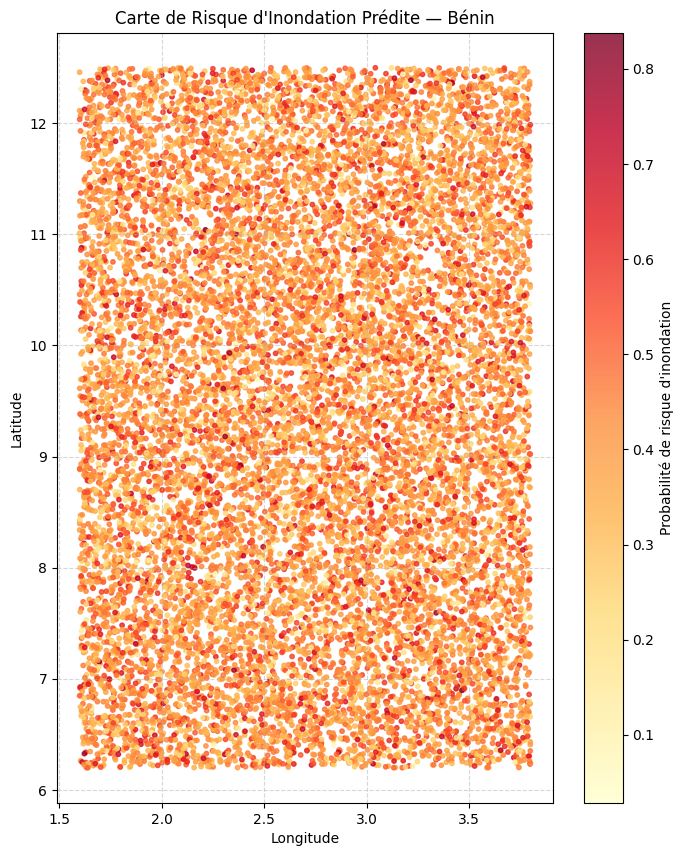

In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Chargement du modèle et du dataset
ensemble_data = joblib.load("data_defi1/processed/ensemble_flood_model.pkl")
df = pd.read_parquet("data_defi1/processed/dataset_advanced.parquet")

features = ensemble_data["features"] + ensemble_data["cat_features"]
X = df[features].copy()
X["landcover"] = X["landcover"].astype("category")

# Prédiction moyenne de l'ensemble (LightGBM + XGBoost + CatBoost)
preds_lgb = np.mean(
    [m.predict_proba(X)[:, 1] for m in ensemble_data["lgb"]], axis=0
)
preds_xgb = np.mean(
    [m.predict_proba(X)[:, 1] for m in ensemble_data["xgb"]], axis=0
)

# Probabilité finale pondérée
df["risk_score"] = (preds_lgb * 0.5) + (preds_xgb * 0.5)

# Visualisation géographique 2D
plt.figure(figsize=(8, 10))
scatter = plt.scatter(
    df["lon"],
    df["lat"],
    c=df["risk_score"],
    cmap="YlOrRd",
    s=10,
    alpha=0.8,
)
plt.colorbar(scatter, label="Probabilité de risque d'inondation")
plt.title("Carte de Risque d'Inondation Prédite — Bénin", fontsize=12)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

/tmp/ipykernel_2525/1308860505.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


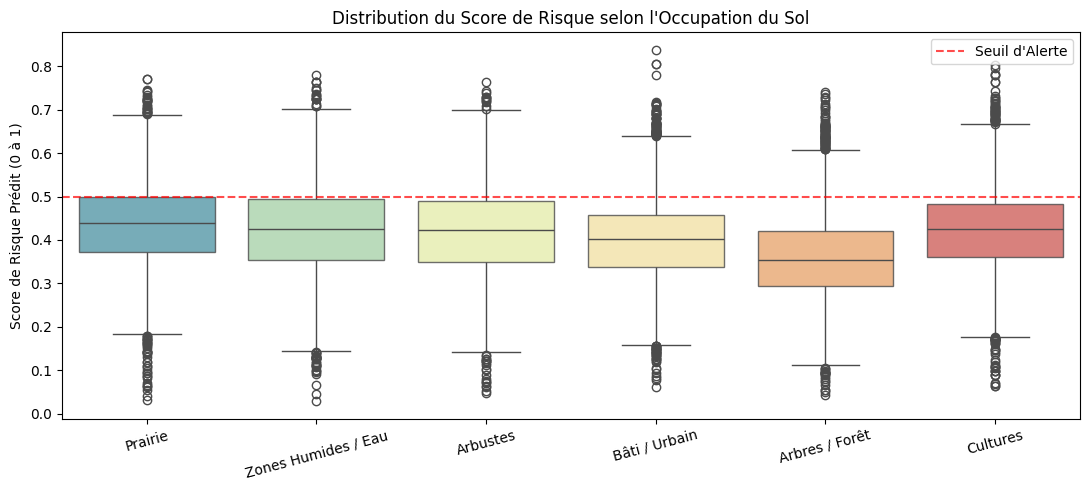

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping des codes ESA WorldCover vers des libellés lisibles
landcover_map = {
    "10": "Arbres / Forêt",
    "20": "Arbustes",
    "30": "Prairie",
    "40": "Cultures",
    "50": "Bâti / Urbain",
    "80": "Zones Humides / Eau",
}

df_plot = df.copy()
df_plot["Type de Sol"] = (
    df_plot["landcover"].astype(str).map(landcover_map).fillna("Autre")
)

plt.figure(figsize=(11, 5))
sns.boxplot(
    data=df_plot,
    x="Type de Sol",
    y="risk_score",
    palette="Spectral_r",
    boxprops=dict(alpha=0.8),
)
plt.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="Seuil d'Alerte")
plt.title(
    "Distribution du Score de Risque selon l'Occupation du Sol", fontsize=12
)
plt.ylabel("Score de Risque Prédit (0 à 1)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

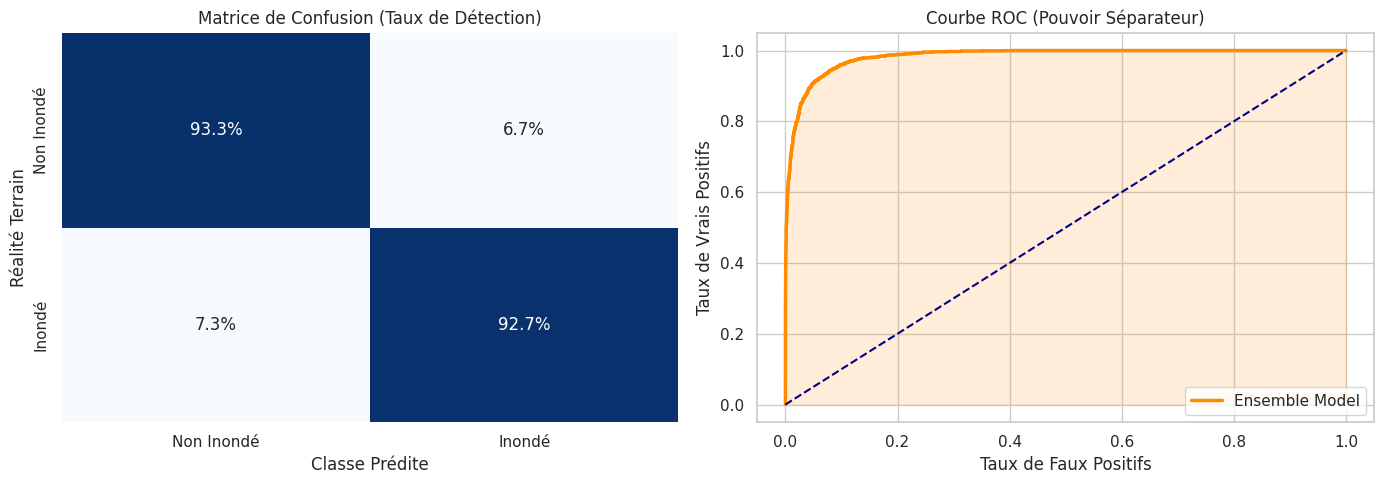

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve

# Configuration du style graphique
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Données réelles vs prédictions
y_true = df["target"]
y_pred_class = (df["risk_score"] > 0.5).astype(int)

# --- Subplot 1 : Matrice de Confusion Normalisée ---
cm = confusion_matrix(y_true, y_pred_class, normalize="true")
sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Non Inondé", "Inondé"],
    yticklabels=["Non Inondé", "Inondé"],
)
axes[0].set_title("Matrice de Confusion (Taux de Détection)", fontsize=12)
axes[0].set_xlabel("Classe Prédite")
axes[0].set_ylabel("Réalité Terrain")

# --- Subplot 2 : Courbe ROC ---
fpr, tpr, _ = roc_curve(y_true, df["risk_score"])
axes[1].plot(fpr, tpr, color="darkorange", lw=2.5, label="Ensemble Model")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].fill_between(fpr, tpr, alpha=0.15, color="darkorange")
axes[1].set_title("Courbe ROC (Pouvoir Séparateur)", fontsize=12)
axes[1].set_xlabel("Taux de Faux Positifs")
axes[1].set_ylabel("Taux de Vrais Positifs")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

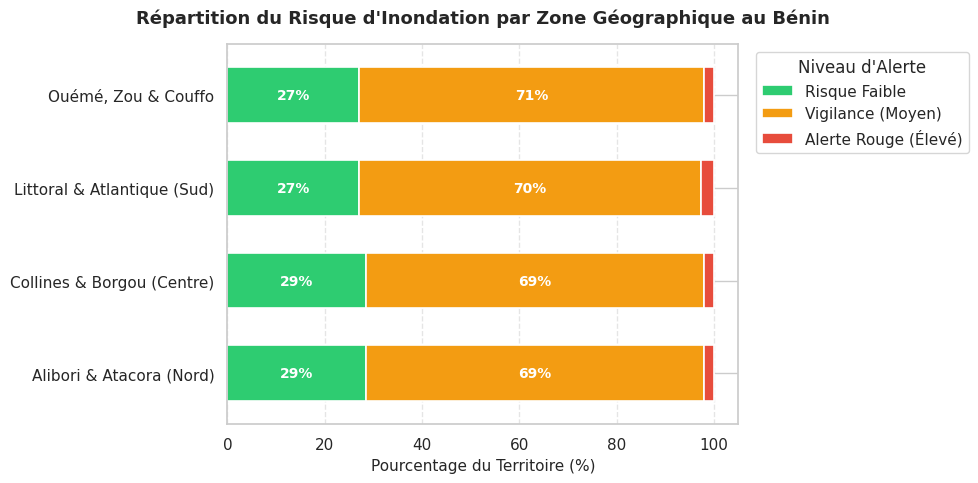

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 1. Attribution approximative des départements du Bénin selon la latitude
def map_benin_region(lat):
    if lat < 6.8:
        return "Littoral & Atlantique (Sud)"
    elif lat < 7.8:
        return "Ouémé, Zou & Couffo"
    elif lat < 9.5:
        return "Collines & Borgou (Centre)"
    else:
        return "Alibori & Atacora (Nord)"


df["Region"] = df["lat"].apply(map_benin_region)

# 2. Catégorisation du niveau de risque en 3 paliers clairs
df["Niveau_Alerte"] = pd.cut(
    df["risk_score"],
    bins=[-0.1, 0.35, 0.65, 1.0],
    labels=["Risque Faible", "Vigilance (Moyen)", "Alerte Rouge (Élevé)"],
)

# 3. Calcul des pourcentages par région
df_pct = (
    pd.crosstab(df["Region"], df["Niveau_Alerte"], normalize="index") * 100
)

# 4. Création du graphique en barres empilées tricolores
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]  # Vert, Orange, Rouge

df_pct.plot(
    kind="barh",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.6,
    edgecolor="white",
    linewidth=1.2,
)

# Habillage visuel
plt.title(
    "Répartition du Risque d'Inondation par Zone Géographique au Bénin",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Pourcentage du Territoire (%)", fontsize=11)
plt.ylabel("")
plt.legend(title="Niveau d'Alerte", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Annotation des pourcentages directement dans les barres
for container in ax.containers:
    labels = [
        f"{val:.0f}%" if val > 8 else "" for val in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [ ]:
!pip install optuna
import optuna
from lightgbm import LGBMClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
    }

    features = [
        "flow_acc",
        "slope",
        "twi",
        "precip_mean",
        "precip_max",
        "precip_anomaly",
    ]
    X = df[features + ["landcover"]].copy()
    X["landcover"] = X["landcover"].astype("category")
    y = df["target"]
    groups = df["spatial_block"]

    gkf = GroupKFold(n_splits=3)
    scores = []

    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(
            **params, class_weight="balanced", random_state=42, n_jobs=-1
        )
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, preds))

    return np.mean(scores)


print("--- Recherche des meilleurs hyperparamètres avec Optuna ---")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print(f"★ Meilleurs Hyperparamètres : {study.best_params}")
print(f"★ Meilleurs Score ROC-AUC CV Spatiale : {study.best_value:.4f}")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

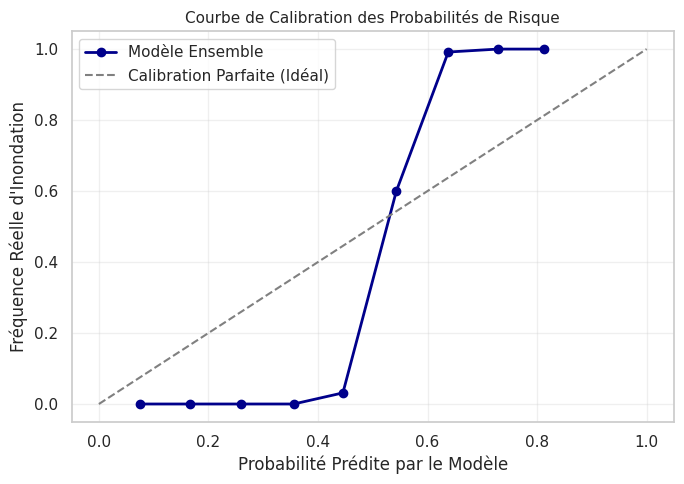

In [ ]:
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve

# Calcul de la courbe de calibration
prob_true, prob_pred = calibration_curve(
    df["target"], df["risk_score"], n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    color="darkblue",
    label="Modèle Ensemble",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Calibration Parfaite (Idéal)",
)

plt.title("Courbe de Calibration des Probabilités de Risque", fontsize=11)
plt.xlabel("Probabilité Prédite par le Modèle")
plt.ylabel("Fréquence Réelle d'Inondation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()